In [1]:
%matplotlib inline

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import scanpy as sc
from starcat import starCAT
from scipy.stats import ttest_ind, fisher_exact, ranksums, wilcoxon
import sys
from statsmodels.stats.multitest import fdrcorrection
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import requests
import openpyxl
import pandas as pd
import numpy as np
from io import BytesIO
from cnmf import cNMF
import scanpy as sc
from scipy.stats import ttest_rel
from sklearn.neighbors import NearestNeighbors
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle
import joblib
import os
from scipy.stats import combine_pvalues

In [2]:
from matplotlib import rcParams, font_manager
import matplotlib


rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

In [3]:
figdir = '../../Figures/Components/Revision'

# Meta-anaysis of % abundance associations

In [4]:
statistic, combined_p_treg = combine_pvalues([0.004, 0.0474, 0.127], method='fisher')
combined_p_treg

0.001641644357843878

# Meta-analysis cGEP associations

In [4]:
melanoma_outdir = '../../Data/Revision/Melanoma_Clinical_GSE120575'
crc_outdir = '../../Data/Revision/CRC_Outcome/'
nmsc_outdir = '../../Data/Revision/BCC_Outcome'

filemap = {
('Melanoma', 'CD4', 'Both'): os.path.join(melanoma_outdir, 'CD4_melanoma_usage_both_gep_association.tsv'),
('Melanoma', 'CD4', 'Pre'): os.path.join(melanoma_outdir, 'CD4_usage_pre_gep_association.tsv'),
('Melanoma', 'CD4', 'Post'): os.path.join(melanoma_outdir, 'CD4_usage_post_gep_association.tsv'),
('Melanoma', 'CD8', 'Both'): os.path.join(melanoma_outdir, 'CD8_usage_both_gep_association.tsv'),
('Melanoma', 'CD8', 'Pre'): os.path.join(melanoma_outdir, 'CD8_usage_pre_gep_association.tsv'),
('Melanoma', 'CD8', 'Post'): os.path.join(melanoma_outdir, 'CD8_usage_post_gep_association.tsv'),
('CRC', 'CD4', 'Both'): os.path.join(crc_outdir, 'CD4_CRC_Combined_usage_both_gep_association.tsv'),
('CRC', 'CD4', 'Post'): os.path.join(crc_outdir, 'CD4_CRC_Post_usage_gep_association.tsv'),
('CRC', 'CD8', 'Both'): os.path.join(crc_outdir, 'CD8_CRC_Combined_usage_both_gep_association.tsv'),
('CRC', 'CD8', 'Post'): os.path.join(crc_outdir, 'CD8_CRC_usage_post_gep_association.tsv'),
('NMSC', 'CD4', 'Both'): os.path.join(nmsc_outdir, 'CD4_nmsc_usage_both_gep_association.tsv'),
('NMSC', 'CD4', 'Pre'): os.path.join(nmsc_outdir, 'CD4_nmsc_usage_pre_gep_association.tsv'),
('NMSC', 'CD4', 'Post'): os.path.join(nmsc_outdir, 'CD4_nmsc_usage_post_gep_association.tsv'),
('NMSC', 'CD8', 'Both'):os.path.join(nmsc_outdir, 'CD8_nmsc_usage_both_gep_association.tsv'),
('NMSC', 'CD8', 'Pre'): os.path.join(nmsc_outdir, 'CD4_nmsc_usage_pre_gep_association.tsv'),
('NMSC', 'CD8', 'Post'): os.path.join(nmsc_outdir, 'CD4_nmsc_usage_post_gep_association.tsv'),
}

full_results = {}
for lin in ['CD4', 'CD8']:
    lindat = []
    for context in ['Both', 'Pre', 'Post']:
        contdat = []

        for cancer in ['Melanoma', 'CRC', 'NMSC']:
            if (cancer == 'CRC') and (context == 'Pre'):
                continue

            if context == 'Both':
                cols_to_keep = ['Beta', 'P']
            else:
                cols_to_keep = ['T', 'P']
            
            dat = pd.read_csv(filemap[(cancer, lin, context)], sep='\t')
            dat.index = dat['GEP']
            dat = dat[cols_to_keep]
            dat.columns = pd.MultiIndex.from_tuples([(context, cancer, c) for c in cols_to_keep])
            contdat.append(dat)
        contdat = pd.concat(contdat, axis=1)
        Ps = contdat.xs('P', axis=1, level=2) / 2

        if context == 'Both':
            cols_to_keep = ['Beta', 'P']
            flip_ind = contdat[(context, 'Melanoma', 'Beta')].apply(np.sign) != contdat[(context, 'CRC', 'Beta')].apply(np.sign)        
            Ps.loc[flip_ind,(context, 'CRC')] = 1 - Ps.loc[flip_ind,(context, 'CRC')]
            flip_ind = contdat[(context, 'Melanoma', 'Beta')].apply(np.sign) != contdat[(context, 'NMSC', 'Beta')].apply(np.sign)        
            Ps.loc[flip_ind,(context, 'NMSC')] = 1 - Ps.loc[flip_ind,(context, 'NMSC')]        
        else:
            cols_to_keep = ['T', 'P']
            flip_ind = contdat[(context, 'Melanoma', 'T')].apply(np.sign) != contdat[(context, 'NMSC', 'T')].apply(np.sign)        
            Ps.loc[flip_ind,(context, 'NMSC')] = 1 - Ps.loc[flip_ind,(context, 'NMSC')]   
            if context == 'Post':
                flip_ind = contdat[(context, 'Melanoma', 'T')].apply(np.sign) != contdat[(context, 'CRC', 'T')].apply(np.sign)        
                Ps.loc[flip_ind,(context, 'CRC')] = 1 - Ps.loc[flip_ind,(context, 'CRC')]

        
        contdat[(context, 'Meta-analysis', 'P')] = Ps.apply(lambda x: combine_pvalues(x, method='fisher')[1], axis=1)
        order = [(context, cancer, val) for cancer in ['Meta-analysis', 'Melanoma', 'CRC', 'NMSC'] for val in cols_to_keep]
        order = [o for o in order if not((o[1] == 'Meta-analysis') and ((o[2] == 'T') or (o[2] == 'Beta')))]
        if context == 'Pre':
            order = [o for o in order if (o[1] != 'CRC')]

        contdat = contdat[order]
        
        lindat.append(contdat)
        
    full_results[lin] = pd.concat(lindat, axis=1)
    full_results[lin] = full_results[lin].sort_values(by=('Both', 'Meta-analysis', 'P'), ascending=True)

In [6]:
full_results['CD4'].sort_values(by=('Pre', 'Meta-analysis', 'P')).head(5)

Both                                              \
                 Meta-analysis  Melanoma                 CRC                 
                             P      Beta         P      Beta             P   
GEP                                                                          
Metallothionein   6.116179e-03  0.787896  0.008230  0.429496  3.736292e-01   
Tph               1.984192e-05  0.783406  0.005397  1.659105  1.598049e-04   
TIMD4/TIM3        1.496091e-07  1.095138  0.000039  1.475586  2.844444e-03   
CellCycle-Late-S  1.943310e-10  0.902079  0.000358  1.956886  1.478323e-07   
CellCycle-S       1.628182e-07  0.620229  0.003944  1.810903  8.126177e-06   

                                               Pre                      \
                      NMSC           Meta-analysis  Melanoma             
                      Beta         P             P         T         P   
GEP                                                                      
Metallothionein   0.426152  0.313620      0.000492  4.540210  0.000346   
Tph              -0.174114  0.697038      0.001891  4.056621  0.001069   
TIMD4/TIM3        0.861264  0.043183      0.003000  2.727771  0.014334   
CellCycle-Late-S  0.675908  0.067777      0.003027  2.831428  0.018335   
CellCycle-S       0.536323  0.165560      0.004155  2.808631  0.018633   

                                              Post                      \
                      NMSC           Meta-analysis  Melanoma             
                         T         P             P         T         P   
GEP                                                                      
Metallothionein   0.673375  0.515231      0.024599  2.440168  0.022094   
Tph               0.339321  0.743046      0.088679  0.798367  0.444293   
TIMD4/TIM3        1.928584  0.092946      0.000230  3.353897  0.005154   
CellCycle-Late-S  2.064250  0.073388      0.000062  3.444725  0.001892   
CellCycle-S       1.798331  0.103236      0.001009  2.827628  0.008826   

                                                          
                       CRC                NMSC            
                         T         P         T         P  
GEP                                                       
Metallothionein   0.484142  0.655951  0.907002  0.393606  
Tph               3.189065  0.044730 -0.979188  0.346816  
TIMD4/TIM3        3.855574  0.021447  1.574985  0.170051  
CellCycle-Late-S  6.325514  0.005817  0.968364  0.374919  
CellCycle-S       3.509237  0.022604  0.655814  0.538334

In [5]:
import pandas as pd
import openpyxl
from openpyxl.styles import PatternFill
from openpyxl.utils.dataframe import dataframe_to_rows
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Collection

def is_collection(variable):
    # Strings are excluded as they are not considered "collections" in this context
    return isinstance(variable, Collection) and not isinstance(variable, (str, bytes))



def create_colored_excel(text_values, text_colors, tabname, filename, vmax=None, vmin=None):
    # Normalize the text_colors DataFrame to map to a colormap
    if vmin is None:
        vmin = text_colors.min().min()

    if vmax is None:
        vmax = text_colors.max().max()
    
    norm = plt.Normalize(vmin, vmax)

    def apply_color(wb, sheet_name, df_values, colors):
        ws = wb[sheet_name]
        # Apply values and colors to the cells
        for r_idx, row in enumerate(dataframe_to_rows(df_values, index=True, header=True)):
            for c_idx, value in enumerate(row):
                cell = ws.cell(row=r_idx+1, column=c_idx+1)
                cell.value = value
                if r_idx > 3:  # Skip header row for coloring
                    # Convert RGB to 
                    rgb = tuple((np.array(colors[r_idx-3][c_idx][:3]) * 255).astype(int))
                    hex_color = f"{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}"
                    cell.fill = PatternFill(start_color=hex_color, end_color=hex_color, fill_type="solid")

    # Create a new workbook and sheet
    wb = openpyxl.Workbook()


    # Create multiple sheets
    ws = wb.active  # The default sheet
    if is_collection(tabname):
        text_colors_mapped = [plt.cm.bwr(norm(x.values)) for x in text_colors]

        ws.title = tabname[0]
        # Apply color and values to the worksheet
        apply_color(wb, tabname[0], text_values[0], text_colors_mapped[0])

        for i in range(1, len(tabname)):
            sheet2 = wb.create_sheet(title=tabname[i])
            apply_color(wb, tabname[i], text_values[i], text_colors_mapped[i])


    else:
        ws = wb.active
        ws.title = tabname
        text_colors_mapped = plt.cm.bwr(norm(text_colors.values)) 

        # Apply color and values to the worksheet
        apply_color(wb, tabname, text_values, text_colors_mapped)

    # Save the workbook
    wb.save(filename)


In [8]:
def prepare_colors(data):
    colors = data.copy()
    newcols = [('Index', 'Index', 'Index')] + list(colors.columns)
    colors[('Index', 'Index', 'Index')] = 0
    colors = colors.loc[:, newcols]
    #newrows = ['Header%d' % x for x in range(1, data.columns.nlevels+1)]
    newrows = ['Header%d' % x for x in range(1, 2)]
    order = newrows + list(data.index)
    for r in newrows:
        colors.loc[r, :] = 1
    colors = colors.loc[order, :]

    
    for cont in colors.columns.get_level_values(0).unique():
        if cont == 'Index':
            colors[('Index', 'Index', 'Index')] = 0
        else:
            for cancer in colors[cont].columns.get_level_values(0).unique():
                if 'T' in colors[cont, cancer].columns:
                    cval = colors[cont, cancer, 'T'].apply(np.sign) * colors[cont, cancer, 'P'].apply(np.log10)* - 1
                    colors[cont, cancer, 'T'] = cval
                    colors[cont, cancer, 'P'] = cval
                elif 'Beta' in colors[cont, cancer].columns:
                    cval = colors[cont, cancer, 'Beta'].apply(np.sign) * colors[cont, cancer, 'P'].apply(np.log10)* - 1
                    colors[cont, cancer, 'Beta'] = cval
                    colors[cont, cancer, 'Beta'] = cval
                else:
                    if cont == 'Both':
                        T = colors[cont].xs('Beta', axis=1, level=1).mean(axis=1)
                    else:
                        T = colors[cont].xs('T', axis=1, level=1).mean(axis=1)
                    colors[cont, cancer, 'P'] = T.apply(np.sign) * colors[cont, cancer, 'P'].apply(np.log10)*-1
    return(colors)

cd4_colors = prepare_colors(full_results['CD4'])
cd8_colors = prepare_colors(full_results['CD8'])
cd4_colors.index.name = None
cd8_colors.index.name = None
full_results['CD4'].index.name = None
full_results['CD8'].index.name = None

create_colored_excel([full_results['CD4'], full_results['CD8']],
                     [cd4_colors, cd8_colors],
                      tabname=['CD4', 'CD8'],
                     filename='../../Tables/Table_S8_ICIassociation.xlsx', vmax=3, vmin=-3)

/tmp/ipykernel_240581/1948736932.py:19: PerformanceWarning: indexing past lexsort depth may impact performance.
  if 'T' in colors[cont, cancer].columns:
/tmp/ipykernel_240581/1948736932.py:23: PerformanceWarning: indexing past lexsort depth may impact performance.
  elif 'Beta' in colors[cont, cancer].columns:
/tmp/ipykernel_240581/1948736932.py:19: PerformanceWarning: indexing past lexsort depth may impact performance.
  if 'T' in colors[cont, cancer].columns:
/tmp/ipykernel_240581/1948736932.py:23: PerformanceWarning: indexing past lexsort depth may impact performance.
  elif 'Beta' in colors[cont, cancer].columns:
/tmp/ipykernel_240581/1948736932.py:19: PerformanceWarning: indexing past lexsort depth may impact performance.
  if 'T' in colors[cont, cancer].columns:
/tmp/ipykernel_240581/1948736932.py:23: PerformanceWarning: indexing past lexsort depth may impact performance.
  elif 'Beta' in colors[cont, cancer].columns:
/tmp/ipykernel_240581/1948736932.py:19: PerformanceWarning: i

# Prepare colorectal

In [7]:
def get_sample_data(counts, usage, scores, obsvars, ind=None, ):
    data = counts.obs[obscols]
    data = pd.concat([data, scores, usage], axis=1)
    if ind is not None:
        data = data.loc[ind, :]
        exprdat = pd.DataFrame(counts[ind, :].X.toarray(), index=counts.obs.index[ind], columns=counts.var.index)
        exprdat = exprdat.groupby(counts.obs.loc[ind, 'sample'].astype(str)).sum()
    else:
        exprdat = pd.DataFrame(counts.X.toarray(), index=data.obs.index, columns=counts.var.index)
        exprdat = exprdat.groupby(counts.obs['sample'].astype(str)).sum()
        
    exprdat = exprdat.div(exprdat.sum(axis=1), axis=0)*1e6
    exprdat = (exprdat + 1).apply(np.log2)

    variables = ['ASA', 'Proliferation'] + list(usage.columns)

    X_full_sample = data.groupby(obsvars)[variables].mean().reset_index().dropna()
    X_full_sample.index = X_full_sample['sample']


    proportions = pd.crosstab(data['sample'], data['Multinomial_Label'])
    proportions = proportions.div(proportions.sum(axis=1), axis=0)
    X_full_sample = pd.merge(left=X_full_sample, right=proportions, left_index=True, right_index=True, how='left')
    variables = variables + list(proportions.columns)

    
    variables = variables + ['TCF7 Expr.', 'SELL Expr.', 'CCR7 Expr.']
    X_full_sample['TCF7 Expr.'] = exprdat.loc[X_full_sample.index, 'TCF7']
    X_full_sample['SELL Expr.'] = exprdat.loc[X_full_sample.index, 'SELL']
    X_full_sample['CCR7 Expr.'] = exprdat.loc[X_full_sample.index, 'CCR7']

    Y_full_sample = X_full_sample['response'].replace({'Non-responder':1, 'Responder':0})
    X = X_full_sample[variables]
    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(X), index=X.index, columns=X.columns)
    X['Intercept'] = 1.0
    display(X_full_sample.head())
    sampinfo = X_full_sample[obsvars]
    return(X, Y_full_sample, sampinfo, scaler, variables)


In [8]:
crc = {}
crc['usage'] = pd.read_csv('../../Data/Revision/CRC_Outcome/GSE205506_combined_counts.T.TCAT.Usage.tsv', sep='\t', index_col=0)
crc['scores'] = pd.read_csv('../../Data/Revision/CRC_Outcome/GSE205506_combined_counts.T.TCAT.Scores.tsv', sep='\t', index_col=0)
crc['adata'] = sc.read('../../Data/Revision/CRC_Outcome/GSE205506_combined_counts.T.h5ad')
sc.pp.filter_genes(crc['adata'], min_cells=10)

obscols = ['sample', 'response', 'timepoint', 'Patient']

ind = (crc['adata'].obs['Type']=='tumor') & crc['scores']['Multinomial_Label'].isin(['CD4_CM', 'CD4_Naive',  'CD4_EM'])
crc['X'], crc['Y'], crc['samp'], crc['scale'], crc['vars'] = get_sample_data(crc['adata'] , crc['usage'] , crc['scores'], obscols, ind=ind, )

/tmp/ipykernel_181713/2470479550.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X_full_sample = data.groupby(obsvars)[variables].mean().reset_index().dropna()
/tmp/ipykernel_181713/2470479550.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y_full_sample = X_full_sample['response'].replace({'Non-responder':1, 'Responder':0})
/tmp/ipykernel_181713/2470479550.py:32: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To ch

,sample,response,timepoint,Patient,ASA,Proliferation,CellCycle-G2M,Translation,HLA,ISG,...,CD40LG/TXNIP,Tph,Exhaustion,Tfh-1,CD4_CM,CD4_EM,CD4_Naive,TCF7 Expr.,SELL Expr.,CCR7 Expr.
sample,,,,,,,,,,,,,,,,,,,,,
P11_tumor_Post,P11_tumor_Post,Responder,Post,P11,0.040719,0.007507,0.000983,0.095519,0.009198,0.020792,...,0.048925,0.015977,0.005737,0.032507,0.546875,0.250000,0.203125,7.902857,6.521813,6.700537
P12_tumor_Post,P12_tumor_Post,Non-responder,Post,P12,0.068176,0.039528,0.005469,0.020245,0.010248,0.017173,...,0.022683,0.051441,0.026786,0.012282,0.444944,0.310112,0.244944,6.261299,4.676968,4.369071
P14_tumor_Post,P14_tumor_Post,Responder,Post,P14,0.057938,0.008426,0.001389,0.139538,0.029207,0.016190,...,0.036536,0.012233,0.011958,0.008120,0.543992,0.224219,0.231788,6.692939,6.185311,7.325380
P15_tumor_Post,P15_tumor_Post,Responder,Post,P15,0.051115,0.006679,0.001103,0.034425,0.039353,0.018023,...,0.054112,0.031333,0.017516,0.010867,0.528411,0.361809,0.109780,6.836427,5.841449,5.368054
P17_tumor_Post,P17_tumor_Post,Responder,Post,P17,0.020506,0.007953,0.001237,0.019086,0.004472,0.037893,...,0.071634,0.012278,0.005255,0.011824,0.349462,0.464158,0.186380,5.899304,4.217664,4.217664


# Prepare melanoma

In [10]:
mel = {}


mel['usage'] = pd.read_csv('../../Data/Revision/Melanoma_Clinical_GSE120575/GSE120575_melanoma_scRNA.TPM.T.TCAT.Usage.tsv', sep='\t', index_col=0)
mel['scores'] = pd.read_csv('../../Data/Revision/Melanoma_Clinical_GSE120575/GSE120575_melanoma_scRNA.TPM.T.TCAT.Scores.tsv', sep='\t', index_col=0)
mel['adata'] = sc.read('../../Data/Revision/Melanoma_Clinical_GSE120575/GSE120575_melanoma_scRNA.TPM.h5ad')
sc.pp.filter_genes(mel['adata'], min_cells=10)

mel['adata'].obs = mel['adata'].obs.rename(columns={'patient':'Patient'})

obscols = ['sample', 'response', 'therapy', 'timepoint', 'Patient']

ind = mel['scores']['Multinomial_Label'].isin(['CD4_Naive', 'CD4_CM', 'CD4_EM']) & ~mel['adata'].obs['CD8+CD39+TIM+_Sorted'] & ~mel['adata'].obs['CD8+CD39-TIM-_Sorted']

mel['X'], mel['Y'], mel['samp'], mel['scale'], mel['vars'] = get_sample_data(mel['adata'] , mel['usage'] , mel['scores'], obscols, ind=ind, )

/tmp/ipykernel_181713/2470479550.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X_full_sample = data.groupby(obsvars)[variables].mean().reset_index().dropna()
/tmp/ipykernel_181713/2470479550.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y_full_sample = X_full_sample['response'].replace({'Non-responder':1, 'Responder':0})
/tmp/ipykernel_181713/2470479550.py:32: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To ch

,sample,response,therapy,timepoint,Patient,ASA,Proliferation,CellCycle-G2M,Translation,HLA,...,CD40LG/TXNIP,Tph,Exhaustion,Tfh-1,CD4_CM,CD4_EM,CD4_Naive,TCF7 Expr.,SELL Expr.,CCR7 Expr.
sample,,,,,,,,,,,,,,,,,,,,,
Post_P1,Post_P1,Responder,anti-PD1,Post,P1,0.060965,0.061449,0.018638,0.034078,0.017630,...,0.005837,0.021209,0.038539,0.007688,0.339181,0.105263,0.555556,4.795775,6.473295,6.157817
Post_P1_2,Post_P1_2,Non-responder,anti-PD1,Post,P1,0.077318,0.025460,0.004466,0.111768,0.011385,...,0.046649,0.030441,0.058772,0.029458,0.435644,0.227723,0.336634,6.801938,7.137129,7.420938
Post_P2,Post_P2,Non-responder,anti-PD1,Post,P2,0.071102,0.071655,0.010816,0.070023,0.016510,...,0.016569,0.058342,0.037956,0.011203,0.509615,0.192308,0.298077,4.403030,6.776071,7.333042
Post_P3,Post_P3,Non-responder,anti-PD1,Post,P3,0.049580,0.034997,0.011731,0.076801,0.026175,...,0.031166,0.022070,0.032462,0.006137,0.454023,0.471264,0.074713,6.400534,5.936012,7.515062
Post_P3_2,Post_P3_2,Non-responder,anti-PD1,Post,P3,0.038787,0.010834,0.002982,0.063660,0.020026,...,0.019980,0.011483,0.025892,0.006725,0.385093,0.447205,0.167702,6.791075,8.231542,8.125760


# Prepare NMSC

In [11]:
nmsc = {}
nmsc['usage'] = pd.read_csv('../../Data/Revision/BCC_Outcome/GSE123813_combined_scRNA_counts.T.TCAT.Usage.tsv', sep='\t', index_col=0)
nmsc['scores'] = pd.read_csv('../../Data/Revision/BCC_Outcome/GSE123813_combined_scRNA_counts.T.TCAT.Scores.tsv', sep='\t', index_col=0)
nmsc['adata'] = sc.read('../../Data/Revision/BCC_Outcome/GSE123813_combined_scRNA_counts.T.h5ad')
nmsc['adata'].obs = nmsc['adata'].obs.rename(columns={'patient':'Patient'})
sc.pp.filter_genes(nmsc['adata'], min_cells=10)
obscols = ['sample', 'response', 'timepoint', 'Tumor Type', 'Patient']

ind = (nmsc['adata'].obs['sort']=='CD45+ CD3+') & nmsc['scores']['Multinomial_Label'].isin(['CD4_CM', 'CD4_Naive',  'CD4_EM']) #& (nmsc['adata'].obs['timepoint']=='Pre')
nmsc['X'], nmsc['Y'], nmsc['samp'], nmsc['scale'], nmsc['vars'] = get_sample_data(nmsc['adata'] , nmsc['usage'] , nmsc['scores'], obscols, ind=ind, )

/tmp/ipykernel_181713/2470479550.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X_full_sample = data.groupby(obsvars)[variables].mean().reset_index().dropna()
/tmp/ipykernel_181713/2470479550.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y_full_sample = X_full_sample['response'].replace({'Non-responder':1, 'Responder':0})
/tmp/ipykernel_181713/2470479550.py:32: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To ch

,sample,response,timepoint,Tumor Type,Patient,ASA,Proliferation,CellCycle-G2M,Translation,HLA,...,CD40LG/TXNIP,Tph,Exhaustion,Tfh-1,CD4_CM,CD4_EM,CD4_Naive,TCF7 Expr.,SELL Expr.,CCR7 Expr.
sample,,,,,,,,,,,,,,,,,,,,,
su001_post,su001_post,Responder,Post,BCC,su001,0.039024,0.010566,0.002387,0.026965,0.006648,...,0.055895,0.025056,0.012620,0.022346,0.592212,0.055165,0.352623,6.850194,8.306286,8.196560
su001_pre,su001_pre,Responder,Pre,BCC,su001,0.035951,0.004989,0.000898,0.071866,0.003399,...,0.062779,0.007183,0.003013,0.008576,0.593750,0.077381,0.328869,6.497392,8.882752,8.223136
su002_post,su002_post,Responder,Post,BCC,su002,0.036343,0.005291,0.000795,0.012781,0.003933,...,0.078920,0.033371,0.017577,0.012236,0.478723,0.329787,0.191489,6.077051,6.275895,8.424300
su003_post,su003_post,Responder,Post,BCC,su003,0.052816,0.004473,0.000934,0.044072,0.003749,...,0.069635,0.034553,0.010183,0.013928,0.618421,0.210526,0.171053,6.302547,6.760493,7.781710
su004_post,su004_post,Responder,Post,BCC,su004,0.045200,0.017615,0.001709,0.034068,0.001593,...,0.046651,0.015573,0.012041,0.084452,0.523364,0.130841,0.345794,7.964074,7.817139,7.830336


In [12]:
features = ['ASA', 'Proliferation', 'TCF7 Expr.', 'CD4-Naive']
X1 = pd.concat([mel['X'][features], mel['samp']], axis=1)
X1['Cancer'] = 'Melanoma'
X2 = pd.concat([crc['X'][features], crc['samp']], axis=1)
X2['Cancer'] = 'CRC'
X3 = pd.concat([nmsc['X'][features], nmsc['samp']], axis=1)
X3['Cancer'] = 'NMSC'
merged = pd.concat([X1, X2, X3], axis=0)
merged.index = list(merged.index)
merged_flat = pd.merge(left=merged.loc[:, features].unstack().reset_index(), right=merged.loc[:, [x for x in merged.columns if x not in features]], left_on='level_1', right_on='sample', how='left')

In [13]:
merged_flat.loc[(merged_flat['Cancer']=='Melanoma') & (merged_flat['level_0']=='ASA'), :]
merged_flat['timepoint_binary'] = merged_flat['timepoint'].replace({'Post':1, 'Pre':0}).astype(float)
merged_flat['response_binary'] = merged_flat['response'].replace({'Non-responder':1, 'Responder':0}).astype(float)
merged_flat['Intercept'] = 1.

/tmp/ipykernel_181713/1647998983.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_flat['timepoint_binary'] = merged_flat['timepoint'].replace({'Post':1, 'Pre':0}).astype(float)
/tmp/ipykernel_181713/1647998983.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  merged_flat['timepoint_binary'] = merged_flat['timepoint'].replace({'Post':1, 'Pre':0}).astype(float)
/tmp/ipykernel_181713/1647998983.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicit

In [14]:
from scipy.stats import combine_pvalues

def run_ols_one(rdat, variables, feature='response', g1lab='Non-responder', g2lab='Responder', covariates=['timepoint']):
    ttest_res = []
    X = rdat[[feature] + covariates]
    X[feature] = X[feature].replace({g1lab:1, g2lab:0}).astype(int)
    X = X.subtract(X.mean(axis=0), axis=1)
    X = X.div(X.std(axis=0), axis=1)
    X['Intercept']= 1
    for v in variables:
        Y = rdat[v] 
        Y = Y - Y.mean(axis=0)
        Y = Y / Y.std()
        model = sm.OLS(Y, X).fit()
        meandiff = rdat.loc[rdat[feature]==g1lab, v].mean() - rdat.loc[rdat[feature]==g2lab, v].mean()
        ttest_res.append([v, model.params[feature], model.pvalues[feature], meandiff])

    ttest_res = pd.DataFrame(ttest_res, columns=['GEP', 'Beta', 'P', 'Delta'])
    ttest_res.index = ttest_res['GEP']

    _, ttest_res.loc[:, 'Q'] =  fdrcorrection(ttest_res.loc[:, 'P'])

    ttest_res['logP'] = ttest_res['P'].apply(np.log10)*-1
    ttest_res['logQ'] = ttest_res['Q'].apply(np.log10)*-1

    ttest_res['signed_logP'] = ttest_res['Beta'].apply(np.sign)*ttest_res['logP']
    return(ttest_res)


from statsmodels.api import MixedLM
from scipy.stats import chi2

def run_mlm(data, fe_cols, group_col, response_col, normalize_response=True):
    if normalize_response:
        Y = data[response_col].copy() - data[response_col].mean()
        Y = Y / Y.std()
    else:
        Y = data[response_col].copy().astype(float)
    
    X = data[fe_cols].copy()    
    model = MixedLM(endog=Y, exog=X, groups=data[group_col], exog_re=None)
    result = model.fit(reml=False)
    return(result)


def run_mlm_multicols(data, fe_cols, group_col, response_cols, normalize_response=True, var_of_interest='response_binary'):
    all_results = []
    full_model_cols = fe_cols
    null_model_cols = [x for x in fe_cols if x != var_of_interest]
    
    for c in response_cols:
        results_null = run_mlm(data, null_model_cols, group_col, c, normalize_response=True)
        results_full = run_mlm(data, full_model_cols, group_col, c, normalize_response=True)
        lrt_stat = 2 * (results_full.llf - results_null.llf)
        df_diff = 1
        lrt_P = chi2.sf(lrt_stat, df_diff)        
        all_results.append([c, results_full.params[var_of_interest], lrt_P])

    all_results = pd.DataFrame(all_results, columns=['GEP', 'Beta', 'P'])
    all_results.index = all_results['GEP']

    _, all_results.loc[:, 'Q'] =  fdrcorrection(all_results.loc[:, 'P'])

    all_results['logP'] = all_results['P'].apply(np.log10)*-1
    all_results['logQ'] = all_results['Q'].apply(np.log10)*-1
    
    return(all_results)

Melanoma ASA 0.008753192602103823
NMSC ASA 0.10230263183292783
CRC ASA 5.082831242119158e-07


/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipykernel_240581/3902086086.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(forlab)


Melanoma Proliferation 0.010305488175876305
NMSC Proliferation 0.040056945366392135


/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipykernel_240581/3902086086.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(forlab)
/tmp/ipykernel_240581/3902086086.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.

CRC Proliferation 2.3411819305613493e-07
Melanoma TCF7 Expr. 0.03665061458618322
NMSC TCF7 Expr. 0.1007972282836059
CRC TCF7 Expr. 0.001096083302607275


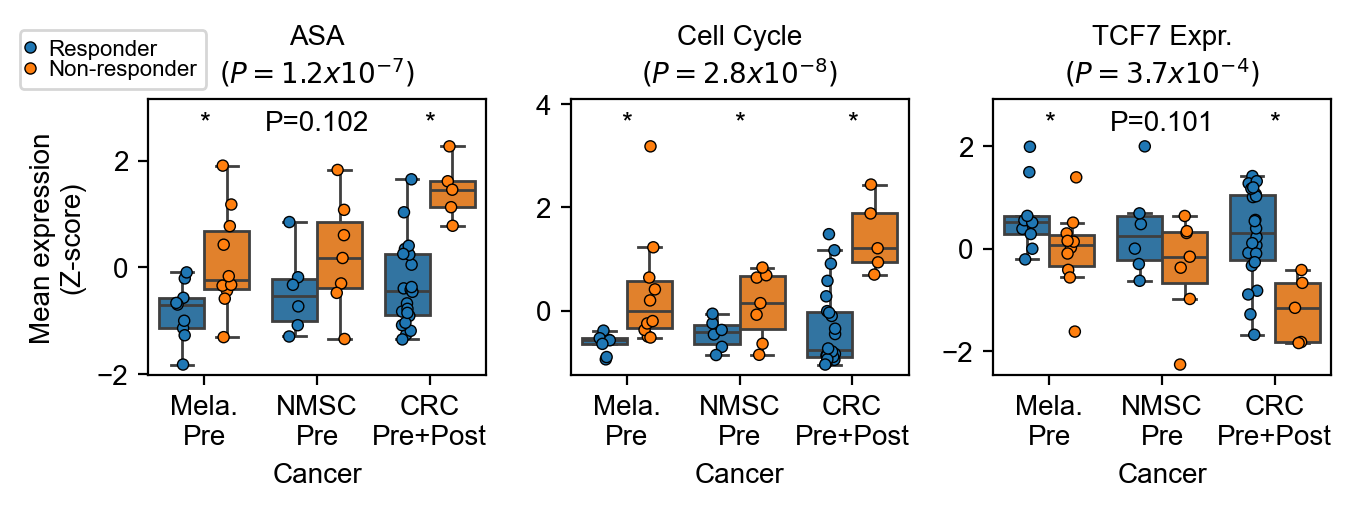

In [42]:
ind = (merged_flat['timepoint']=='Pre') | (merged_flat['Cancer']=='CRC')
merged_flat_pre = merged_flat.loc[ind, :]

order = ['Melanoma', 'NMSC', 'CRC',]
forlab = ['Mela.\nPre', 'NMSC\nPre', 'CRC\nPre+Post']
hue_order = ['Responder', 'Non-responder']
(fig,axes) = plt.subplots(1,3, figsize=(7,2), dpi=200, gridspec_kw={'wspace':0.25, 'top':.8, 'right':.97})

ax_legend = fig.add_axes([0.05, .8, .1, .2])

all_Ps = []
meta_p = []

for i,feature in enumerate(['ASA', 'Proliferation', 'TCF7 Expr.']):
    subdat = merged_flat_pre.loc[merged_flat_pre['level_0']==feature, :]
    
    sns.stripplot(x='Cancer', y=0, hue='response', data=subdat, dodge=True, ax=axes[i], order=order, hue_order=hue_order, legend=True,
                  edgecolor='0', linewidth=.5, s=4)

        
    sns.boxplot(x='Cancer', y=0, hue='response', data=subdat, dodge=True, ax=axes[i], order=order, hue_order=hue_order, legend=False,
                  fliersize=0)


    if i == 0:
        handles, labels = axes[i].get_legend_handles_labels()
        ax_legend.legend(handles=handles, labels=labels, loc='center', fontsize=8,  handlelength=0.08, borderaxespad=0, labelspacing=0.02)
        ax_legend.axis('off')  # Hide the axis frame and ticks
    axes[i].get_legend().remove()

    
    ylim = axes[i].get_ylim()
    ylen = ylim[1] - ylim[0]
    plotheight = ylim[0] + ylen*1.05

    Ps = []
    for j,c in enumerate(order):
        cdat = subdat.loc[subdat['Cancer']==c, :]
        if c != 'CRC':
            H,P = ttest_ind(cdat.loc[cdat['response']=='Non-responder', 0], cdat.loc[cdat['response']=='Responder', 0], nan_policy='raise', equal_var=False)
        else:
            res = run_mlm_multicols(cdat, ['timepoint_binary', 'response_binary', 'Intercept'], 'Patient', [0], normalize_response=True, var_of_interest='response_binary')
            H = res.loc[0, 'Beta']
            P = res.loc[0, 'P']
            #model = sm.OLS(cdat[0], cdat[['timepoint_binary', 'response_binary', 'Intercept']]).fit()
            #H = model.params['response_binary']
            #P = model.pvalues['response_binary']

        P = P / 2 # one-tailed test given concordant directions with prior expectation

        all_Ps.append([c, feature, H, P])

        Ps.append(P)
        print(c, feature, P)

        if P <= .05:
            axes[i].text(j, plotheight, '*', fontsize=10, ha='center', va='center')
        elif P < .25:
            if j == 0:
                axes[i].text(j+.1, plotheight, f'P={P:.3f}', fontsize=10, ha='center', va='center')
            elif j == 1:
                axes[i].text(j, plotheight, f'P={P:.3f}', fontsize=10, ha='center', va='center')
            elif j == 2:
                axes[i].text(j-.1, plotheight, f'P={P:.3f}', fontsize=10, ha='center', va='center')
            
        else:
            axes[i].text(j, plotheight, 'NS', fontsize=10, ha='center', va='center')

    statistic, combined_p = combine_pvalues(Ps, method='fisher')
    meta_p.append([feature, combined_p,  statistic])


    axes[i].set_ylim(ylim[0], ylim[0]+ylen*1.15)
    
    axes[i].set_xticklabels(forlab)
    axes[i].set_xlabel
    exponent = np.round(np.ceil(np.log10(combined_p)), decimals=0)
    base = str(np.round((combined_p / (10**exponent))*10, decimals=1))
    exponent = str(int(exponent)-1)
    titlestr = feature.replace('Proliferation', 'Cell Cycle') + '\n$(P=' +base+'x10^{' + exponent+'})$'     
    axes[i].set_title(titlestr, fontsize=10)
    if i == 0:
        axes[i].set_ylabel('Mean expression\n(Z-score)', fontsize=10)
    else:
        axes[i].set_ylabel('')

#plt.savefig(os.path.join(figdir, 'AllCancer_StripBoxplot.png'))
#plt.savefig(os.path.join(figdir, 'AllCancer_StripBoxplot.pdf'))

In [15]:
ind = (merged_flat['timepoint']=='Pre') | (merged_flat['Cancer']=='CRC')
merged_flat_pre = merged_flat.loc[ind, :]


In [26]:
merged_flat_pre[['Cancer', 'response', 'Patient'
                ]].drop_duplicates().groupby(['Cancer', 'response'])['Patient'].count()


/tmp/ipykernel_181713/2688793730.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ]].drop_duplicates().groupby(['Cancer', 'response'])['Patient'].count()


Cancer    response     
CRC       Non-responder     4
          Responder        15
Melanoma  Non-responder    10
          Responder         9
NMSC      Non-responder     7
          Responder         6
Name: Patient, dtype: int64

In [29]:
merged_flat_pre[['Cancer', 'response', 'Patient', 'level_0',
                ]].drop_duplicates().groupby(['level_0','response', 'Cancer'])['Patient'].count()


/tmp/ipykernel_181713/346435398.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ]].drop_duplicates().groupby(['level_0','response', 'Cancer'])['Patient'].count()


level_0        response       Cancer  
ASA            Non-responder  CRC          4
                              Melanoma    10
                              NMSC         7
               Responder      CRC         15
                              Melanoma     9
                              NMSC         6
CD4-Naive      Non-responder  CRC          4
                              Melanoma    10
                              NMSC         7
               Responder      CRC         15
                              Melanoma     9
                              NMSC         6
Proliferation  Non-responder  CRC          4
                              Melanoma    10
                              NMSC         7
               Responder      CRC         15
                              Melanoma     9
                              NMSC         6
TCF7 Expr.     Non-responder  CRC          4
                              Melanoma    10
                              NMSC         7
               R

In [43]:
all_Ps = pd.DataFrame(all_Ps, columns=['Cancer', 'Feature', 'H', 'P'])
all_Ps

,Cancer,Feature,H,P
0,Melanoma,ASA,2.680191,8.753193e-03
1,NMSC,ASA,1.350206,1.023026e-01
2,CRC,ASA,1.925711,5.082831e-07
3,Melanoma,Proliferation,2.772543,1.030549e-02
4,NMSC,Proliferation,1.986489,4.005695e-02
5,CRC,Proliferation,1.918047,2.341182e-07
6,Melanoma,TCF7 Expr.,-1.908921,3.665061e-02
7,NMSC,TCF7 Expr.,-1.359089,1.007972e-01
8,CRC,TCF7 Expr.,-1.501927,1.096083e-03


In [44]:
combine_pvalues([all_Ps.loc[0, 'P'], all_Ps.loc[1, 'P']], method='fisher')

SignificanceResult(statistic=14.036313312175162, pvalue=0.007180055946161972)

In [45]:
combine_pvalues([all_Ps.loc[3, 'P'], all_Ps.loc[4, 'P']], method='fisher')

SignificanceResult(statistic=15.585063792313687, pvalue=0.003629613235259359)

In [46]:
pd.DataFrame(meta_p, columns=['feature', 'combined_P', 'combined_T'])

,feature,combined_P,combined_T
0,ASA,1.155450e-07,43.020768
1,Proliferation,2.802150e-08,46.119943
2,TCF7 Expr.,3.664873e-04,24.833963


Melanoma ASA 0.008753192602103823
NMSC ASA 0.10230263183292783
CRC ASA 5.082831242119158e-07


/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipykernel_240581/4069154442.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(forlab)


Melanoma Proliferation 0.010305488175876305
NMSC Proliferation 0.040056945366392135


/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/PHShome/dk718/miniforge3/envs/py310/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipykernel_240581/4069154442.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(forlab)
/tmp/ipykernel_240581/4069154442.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.

CRC Proliferation 2.3411819305613493e-07
Melanoma CD4-Naive 0.01737449463608595
NMSC CD4-Naive 0.044096660696447215
CRC CD4-Naive 0.04967878193967227


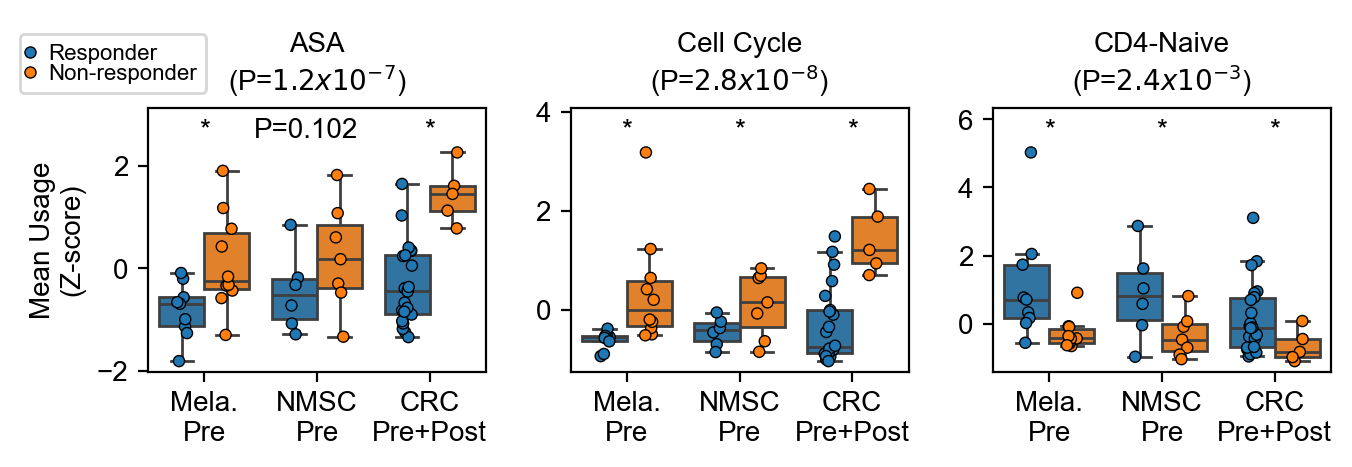

In [47]:
ind = (merged_flat['timepoint']=='Pre') | (merged_flat['Cancer']=='CRC')
merged_flat_pre = merged_flat.loc[ind, :]

order = ['Melanoma',  'NMSC', 'CRC']
forlab = ['Mela.\nPre', 'NMSC\nPre', 'CRC\nPre+Post']
hue_order = ['Responder', 'Non-responder']
(fig,axes) = plt.subplots(1,3, figsize=(7,2.2), dpi=200, gridspec_kw={'wspace':0.25, 'top':.8, 'right':.97, 'bottom':.2})

ax_legend = fig.add_axes([0.05, .8, .1, .2])
meta_p = []
all_Ps = []


for i,feature in enumerate(['ASA', 'Proliferation', 'CD4-Naive']):
    subdat = merged_flat_pre.loc[merged_flat_pre['level_0']==feature, :]

    sns.stripplot(x='Cancer', y=0, hue='response', data=subdat, dodge=True, ax=axes[i], order=order, hue_order=hue_order, legend=True,
                  edgecolor='0', linewidth=.5, s=4)

        
    sns.boxplot(x='Cancer', y=0, hue='response', data=subdat, dodge=True, ax=axes[i], order=order, hue_order=hue_order, legend=False,
                  fliersize=0)


    if i == 0:
        handles, labels = axes[i].get_legend_handles_labels()
        ax_legend.legend(handles=handles, labels=labels, loc='center', fontsize=8,  handlelength=0.08, borderaxespad=0, labelspacing=0.02)
        ax_legend.axis('off')  # Hide the axis frame and ticks
    axes[i].get_legend().remove()

    
    ylim = axes[i].get_ylim()
    ylen = ylim[1] - ylim[0]
    plotheight = ylim[0] + ylen*1.05

    Ps= [] 
    for j,c in enumerate(order):
        cdat = subdat.loc[subdat['Cancer']==c, :]
        if c != 'CRC':
            H,P = ttest_ind(cdat.loc[cdat['response']=='Non-responder', 0], cdat.loc[cdat['response']=='Responder', 0], nan_policy='raise', equal_var=False)
        else:
            res = run_mlm_multicols(cdat, ['timepoint_binary', 'response_binary', 'Intercept'], 'Patient', [0], normalize_response=True, var_of_interest='response_binary')
            H = res.loc[0, 'Beta']
            P = res.loc[0, 'P']
            #model = sm.OLS(cdat[0], cdat[['timepoint_binary', 'response_binary', 'Intercept']]).fit()
            #H = model.params['response_binary']
            #P = model.pvalues['response_binary']

        P = P / 2 # one-tailed test given concordant directions with prior expectation        
        Ps.append(P)
        all_Ps.append([c, feature, H, P])

        print(c, feature, P)

        if P <= .05:
            axes[i].text(j, plotheight, '*', fontsize=10, ha='center', va='center')
        elif P < .25:
            if j == 0:
                axes[i].text(j+.1, plotheight, f'P={P:.3f}', fontsize=10, ha='center', va='center')
            elif j == 1:
                axes[i].text(j-.1, plotheight, f'P={P:.3f}', fontsize=10, ha='center', va='center')
            elif j == 2:
                axes[i].text(j-.1, plotheight, f'P={P:.3f}', fontsize=10, ha='center', va='center')
            
        else:
            axes[i].text(j, plotheight, 'NS', fontsize=10, ha='center', va='center')

    statistic, combined_p = combine_pvalues(Ps, method='fisher')
    meta_p.append([feature, combined_p,  statistic])



    axes[i].set_ylim(ylim[0], ylim[0]+ylen*1.15)
    
    axes[i].set_xticklabels(forlab)
    axes[i].set_xlabel('')
    exponent = np.round(np.ceil(np.log10(combined_p)), decimals=0)
    base = str(np.round((combined_p / (10**exponent))*10, decimals=1))
    exponent = str(int(exponent)-1)
    titlestr = feature.replace('Proliferation', 'Cell Cycle') + '\n(P=$' +base+'x10^{' + exponent+'}$)'     
    axes[i].set_title(titlestr, fontsize=10)
    if i == 0:
        axes[i].set_ylabel('Mean Usage\n(Z-score)', fontsize=10)
    else:
        axes[i].set_ylabel('')

plt.savefig(os.path.join(figdir, 'AllCancer_StripBoxplot.png'))
plt.savefig(os.path.join(figdir, 'AllCancer_StripBoxplot.pdf'))

In [48]:
all_Ps = pd.DataFrame(all_Ps, columns=['Cancer', 'Feature', 'H', 'P'])
all_Ps

,Cancer,Feature,H,P
0,Melanoma,ASA,2.680191,8.753193e-03
1,NMSC,ASA,1.350206,1.023026e-01
2,CRC,ASA,1.925711,5.082831e-07
3,Melanoma,Proliferation,2.772543,1.030549e-02
4,NMSC,Proliferation,1.986489,4.005695e-02
5,CRC,Proliferation,1.918047,2.341182e-07
6,Melanoma,CD4-Naive,-2.478333,1.737449e-02
7,NMSC,CD4-Naive,-1.980389,4.409666e-02
8,CRC,CD4-Naive,-0.827125,4.967878e-02


In [49]:
combine_pvalues([all_Ps.loc[6, 'P'], all_Ps.loc[7, 'P']], method='fisher')

SignificanceResult(statistic=14.348246388425, pvalue=0.006262663295934761)

In [50]:
pd.DataFrame(meta_p, columns=['feature', 'combined_P', 'combined_T'])

,feature,combined_P,combined_T
0,ASA,1.155450e-07,43.020768
1,Proliferation,2.802150e-08,46.119943
2,CD4-Naive,2.396172e-03,20.352601


In [51]:
features = ['TCF7 Expr.', 'SELL Expr.', 'CCR7 Expr.']
X1 = pd.concat([mel['X'][features], mel['samp']], axis=1)
X1['Cancer'] = 'Melanoma'
X2 = pd.concat([crc['X'][features], crc['samp']], axis=1)
X2['Cancer'] = 'CRC'
X3 = pd.concat([nmsc['X'][features], nmsc['samp']], axis=1)
X3['Cancer'] = 'NMSC'
merged = pd.concat([X1, X2, X3], axis=0)
merged.index = list(merged.index)
merged_flat = pd.merge(left=merged.loc[:, features].unstack().reset_index(), right=merged.loc[:, [x for x in merged.columns if x not in features]], left_on='level_1', right_on='sample', how='left')

merged_flat['timepoint_binary'] = merged_flat['timepoint'].replace({'Post':1, 'Pre':0}).astype(float)
merged_flat['response_binary'] = merged_flat['response'].replace({'Non-responder':1, 'Responder':0}).astype(float)
merged_flat['Intercept'] = 1.

merged_flat

,level_0,level_1,0,sample,response,therapy,timepoint,Patient,Cancer,Tumor Type,timepoint_binary,response_binary,Intercept
0,TCF7 Expr.,Post_P1,-1.064968,Post_P1,Responder,anti-PD1,Post,P1,Melanoma,NaN,1.0,0.0,1.0
1,TCF7 Expr.,Post_P1_2,0.494934,Post_P1_2,Non-responder,anti-PD1,Post,P1,Melanoma,NaN,1.0,1.0,1.0
2,TCF7 Expr.,Post_P2,-1.370349,Post_P2,Non-responder,anti-PD1,Post,P2,Melanoma,NaN,1.0,1.0,1.0
3,TCF7 Expr.,Post_P3,0.182820,Post_P3,Non-responder,anti-PD1,Post,P3,Melanoma,NaN,1.0,1.0,1.0
4,TCF7 Expr.,Post_P3_2,0.486487,Post_P3_2,Non-responder,anti-PD1,Post,P3,Melanoma,NaN,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,CCR7 Expr.,su012_pre,-0.541769,su012_pre,Responder,NaN,Pre,su012,NMSC,BCC,0.0,0.0,1.0
302,CCR7 Expr.,su013_post,-0.292070,su013_post,Non-responder,NaN,Post,su013,NMSC,SCC,1.0,1.0,1.0
303,CCR7 Expr.,su013_pre,1.020456,su013_pre,Non-responder,NaN,Pre,su013,NMSC,SCC,0.0,1.0,1.0
304,CCR7 Expr.,su014_post,-1.578111,su014_post,Non-responder,NaN,Post,su014,NMSC,SCC,1.0,1.0,1.0


Melanoma TCF7 Expr. -1.9089214916601076 0.03665061458618322
NMSC TCF7 Expr. -1.3590885694877208 0.1007972282836059
CRC TCF7 Expr. -1.5019266159046685 0.001096083302607275
combined TCF7 Expr. 0.0003664873006068746
Melanoma SELL Expr. -3.31863466317663 0.0023669550520004717
NMSC SELL Expr. -1.5996947640634336 0.07183392083777342
CRC SELL Expr. -0.13459176111940963 0.39980867658570063
combined SELL Expr. 0.0038503710584331195


/tmp/ipykernel_240581/810886698.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(forlab)
/tmp/ipykernel_240581/810886698.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(forlab)
/tmp/ipykernel_240581/810886698.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(forlab)


Melanoma CCR7 Expr. -3.81074464555091 0.0007578919247743261
NMSC CCR7 Expr. -1.752712989440627 0.05661261662147224
CRC CCR7 Expr. -0.9281902032223964 0.030229906333756582
combined CCR7 Expr. 0.00013804532103296185


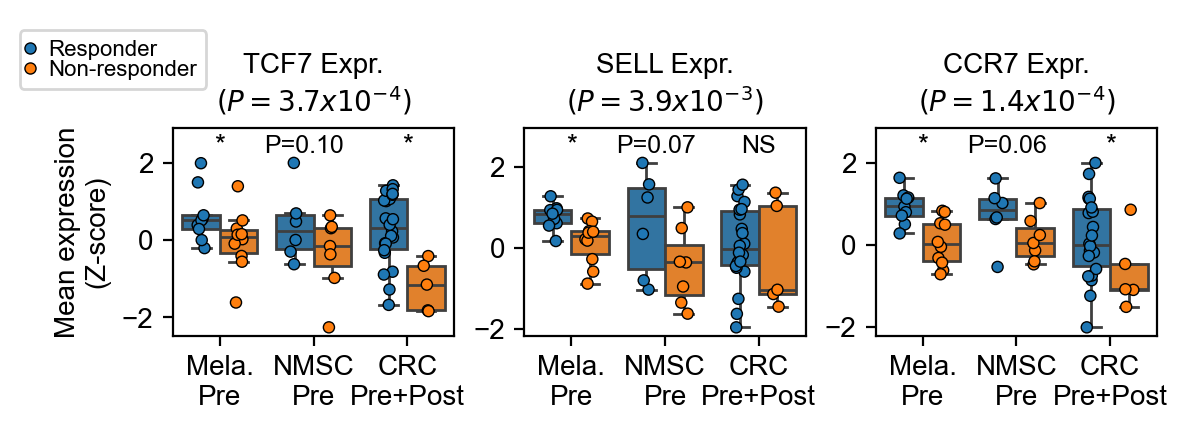

In [52]:
ind = (merged_flat['timepoint']=='Pre') | (merged_flat['Cancer']=='CRC')
merged_flat_pre = merged_flat.loc[ind, :]

order = ['Melanoma', 'NMSC', 'CRC']
forlab = ['Mela.\nPre', 'NMSC\nPre', 'CRC\nPre+Post']
hue_order = ['Responder', 'Non-responder']
(fig,axes) = plt.subplots(1,3, figsize=(6,2.), dpi=200, gridspec_kw={'wspace':0.25, 'left':0.15, 'top':.72, 'right':.97, 'bottom':.2})

ax_legend = fig.add_axes([0.05, .79, .1, .2])
meta_p = []
all_Ps = []

for i,feature in enumerate(['TCF7 Expr.', 'SELL Expr.', 'CCR7 Expr.']):
    subdat = merged_flat_pre.loc[merged_flat_pre['level_0']==feature, :]

    sns.stripplot(x='Cancer', y=0, hue='response', data=subdat, dodge=True, ax=axes[i], order=order, hue_order=hue_order, legend=True,
                  edgecolor='0', linewidth=.5, s=4)

        
    sns.boxplot(x='Cancer', y=0, hue='response', data=subdat, dodge=True, ax=axes[i], order=order, hue_order=hue_order, legend=False,
                  fliersize=0)


    if i == 0:
        handles, labels = axes[i].get_legend_handles_labels()
        ax_legend.legend(handles=handles, labels=labels, loc='center', fontsize=8,  
                         handlelength=0.08, borderaxespad=0, labelspacing=0.02)
        ax_legend.axis('off')  # Hide the axis frame and ticks
    axes[i].get_legend().remove()

    
    ylim = axes[i].get_ylim()
    ylen = ylim[1] - ylim[0]
    plotheight = ylim[0] + ylen*1.05
    Ps= [] 
    
    for j,c in enumerate(order):
        cdat = subdat.loc[subdat['Cancer']==c, :]
        if c != 'CRC':
            H,P = ttest_ind(cdat.loc[cdat['response']=='Non-responder', 0], cdat.loc[cdat['response']=='Responder', 0], nan_policy='raise', equal_var=False)
        else:
            res = run_mlm_multicols(cdat, ['timepoint_binary', 'response_binary', 'Intercept'], 'Patient', [0], normalize_response=True, var_of_interest='response_binary')
            H = res.loc[0, 'Beta']
            P = res.loc[0, 'P']
            #model = sm.OLS(cdat[0], cdat[['timepoint_binary', 'response_binary', 'Intercept']]).fit()
            #H = model.params['response_binary']
            #P = model.pvalues['response_binary']

        P = P / 2 # one-tailed test given concordant directions with prior expectation        
        all_Ps.append([c, feature, H, P])
        
        print(c, feature, H, P)
        Ps.append(P)

        if P <= .05:
            axes[i].text(j, plotheight, '*', fontsize=10, ha='center', va='center')
        elif P < .25:
            if j == 0:
                axes[i].text(j+.1, plotheight, f'P={P:.2f}', fontsize=9, ha='center', va='center')
            elif j in [1,2]:
                axes[i].text(j-.1, plotheight, f'P={P:.2f}', fontsize=9, ha='center', va='center')
            
        else:
            axes[i].text(j, plotheight, 'NS', fontsize=9, ha='center', va='center')

    statistic, combined_p = combine_pvalues(Ps, method='fisher')
    print('combined', feature, combined_p)
    meta_p.append([feature, combined_p,  statistic])

    axes[i].set_ylim(ylim[0], ylim[0]+ylen*1.15)
    
    axes[i].set_xticklabels(forlab)
    axes[i].set_xlabel('')
    exponent = np.round(np.ceil(np.log10(combined_p)), decimals=0)
    base = str(np.round((combined_p / (10**exponent))*10, decimals=1))
    exponent = str(int(exponent)-1)
    titlestr = feature.replace('Proliferation', 'Cell Cycle') + '\n$(P=' +base+'x10^{' + exponent+'})$'     
    axes[i].set_title(titlestr, fontsize=10)
    if i == 0:
        axes[i].set_ylabel('Mean expression\n(Z-score)', fontsize=10)
    else:
        axes[i].set_ylabel('')

plt.savefig(os.path.join(figdir, 'AllCancer_StripBoxplot_NaiveMarkerExpression.png'))
plt.savefig(os.path.join(figdir, 'AllCancer_StripBoxplot_NaiveMarkerExpression.pdf'))

In [53]:
all_Ps = pd.DataFrame(all_Ps, columns=['Cancer', 'Feature', 'H', 'P'])
all_Ps

,Cancer,Feature,H,P
0,Melanoma,TCF7 Expr.,-1.908921,0.036651
1,NMSC,TCF7 Expr.,-1.359089,0.100797
2,CRC,TCF7 Expr.,-1.501927,0.001096
3,Melanoma,SELL Expr.,-3.318635,0.002367
4,NMSC,SELL Expr.,-1.599695,0.071834
5,CRC,SELL Expr.,-0.134592,0.399809
6,Melanoma,CCR7 Expr.,-3.810745,0.000758
7,NMSC,CCR7 Expr.,-1.752713,0.056613
8,CRC,CCR7 Expr.,-0.928190,0.030230


In [54]:
combine_pvalues([all_Ps.loc[0, 'P'], all_Ps.loc[1, 'P']], method='fisher')

SignificanceResult(statistic=11.201939005271573, pvalue=0.024385832024725947)

In [55]:
combine_pvalues([all_Ps.loc[3, 'P'], all_Ps.loc[4, 'P']], method='fisher')

SignificanceResult(statistic=17.35909883498457, pvalue=0.001645791155043219)

In [56]:
combine_pvalues([all_Ps.loc[6, 'P'], all_Ps.loc[7, 'P']], method='fisher')

SignificanceResult(statistic=20.112986344095095, pvalue=0.00047439260463478746)

In [57]:
def get_lineage_frequency(dat):
    lineages = ['CD4_Naive', 'CD4_CM', 'CD4_EM', 'Treg']
    overlap = dat['scores']['Multinomial_Label'].index.intersection(dat['adata'].obs.index)
    s = dat['scores'].loc[overlap, :]
    obs = dat['adata'].obs.loc[overlap, 'sample']
    ind = s['Multinomial_Label'].isin(lineages)
    s = s.loc[ind, :]
    obs = obs.loc[ind]
    ct = pd.crosstab(obs, s['Multinomial_Label'])
    ct_merge = pd.merge(left=ct, right=dat['samp'], how='left', left_index=True, right_index=True)
    ct_merge['total_cd4s'] = ct_merge[lineages].sum(axis=1)
    ct_merge['frac_naive'] = (ct_merge['CD4_Naive'] / ct_merge['total_cd4s']) * 100
    return(ct_merge)

mel_frac_naive = get_lineage_frequency(mel)
mel_frac_naive['Cancer'] = 'Mela.'
crc_frac_naive = get_lineage_frequency(crc)
crc_frac_naive['Cancer'] = 'CRC'
nmsc_frac_naive = get_lineage_frequency(nmsc)
nmsc_frac_naive['Cancer'] = 'NMSC'
merged_flat_frac = pd.concat([mel_frac_naive, crc_frac_naive, nmsc_frac_naive], axis=0)
merged_flat_frac['timepoint_binary'] = merged_flat_frac['timepoint'].replace({'Post':1, 'Pre':0}).astype(float)
merged_flat_frac['response_binary'] = merged_flat_frac['response'].replace({'Non-responder':1, 'Responder':0}).astype(float)
merged_flat_frac['Intercept'] = 1.
merged_flat_frac = merged_flat_frac.loc[~merged_flat_frac['sample'].isnull(), :] # Filter out normal CRCs


ind = (merged_flat_frac['timepoint']=='Pre') | (merged_flat_frac['Cancer']=='CRC')
merged_flat_frac_pre = merged_flat_frac.loc[ind, :]



merged_flat_frac_pre.head()

,CD4_CM,CD4_EM,CD4_Naive,Treg,sample,response,therapy,timepoint,Patient,total_cd4s,frac_naive,Cancer,Tumor Type,timepoint_binary,response_binary,Intercept
sample,,,,,,,,,,,,,,,,
Pre_P1,38,27,30,10,Pre_P1,Responder,anti-CTLA4,Pre,P1,105,28.571429,Mela.,NaN,0.0,0.0,1.0
Pre_P2,26,18,22,24,Pre_P2,Non-responder,anti-PD1,Pre,P2,90,24.444444,Mela.,NaN,0.0,1.0,1.0
Pre_P3,38,49,42,15,Pre_P3,Non-responder,anti-PD1,Pre,P3,144,29.166667,Mela.,NaN,0.0,1.0,1.0
Pre_P4,27,15,33,10,Pre_P4,Non-responder,anti-CTLA4+PD1,Pre,P4,85,38.823529,Mela.,NaN,0.0,1.0,1.0
Pre_P6,46,3,7,4,Pre_P6,Non-responder,anti-CTLA4,Pre,P6,60,11.666667,Mela.,NaN,0.0,1.0,1.0


Mela. frac_naive 0.08068301401744461
NMSC frac_naive 0.028394769773582157
CRC frac_naive 0.4760043143461361
combined frac_naive 0.0338984711054175


/tmp/ipykernel_240581/1523069620.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(forlab)


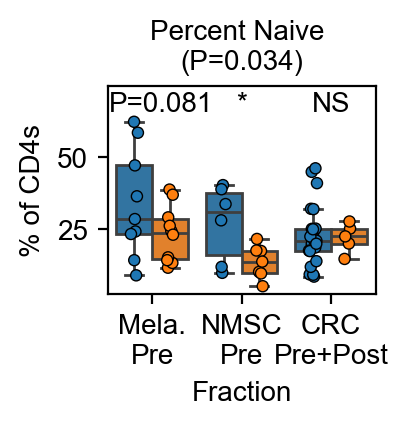

In [64]:
order = ['Mela.', 'NMSC', 'CRC']
forlab = ['Mela.\nPre', 'NMSC\nPre', 'CRC\nPre+Post']
hue_order = ['Responder', 'Non-responder']
(fig,ax) = plt.subplots(1,1, figsize=(2., 2.), dpi=200, gridspec_kw={'wspace':0.25, 'left':0.3, 'top':.72, 'right':.97, 'bottom':.2})
feature = 'frac_naive'
meta_p = []
sns.stripplot(x='Cancer', y='frac_naive', hue='response', data=merged_flat_frac_pre, dodge=True, ax=ax, order=order, hue_order=hue_order, legend=True,
                  edgecolor='0', linewidth=.5, s=4)

        
sns.boxplot(x='Cancer', y='frac_naive', hue='response', data=merged_flat_frac_pre, dodge=True, ax=ax, order=order, hue_order=hue_order, legend=False,
                  fliersize=0)
ax.get_legend().remove()

    
ylim = ax.get_ylim()
ylen = ylim[1] - ylim[0]
plotheight = ylim[0] + ylen*1.05

Ps= [] 
all_Ps = []

for j,c in enumerate(order):
    cdat = merged_flat_frac_pre.loc[merged_flat_frac_pre['Cancer']==c, :]
    if c != 'CRC':
        H,P = ttest_ind(cdat.loc[cdat['response']=='Non-responder', 'frac_naive'], cdat.loc[cdat['response']=='Responder', 'frac_naive'], nan_policy='raise', equal_var=False)
    else:
        res = run_mlm_multicols(cdat, ['timepoint_binary', 'response_binary', 'Intercept'], 'Patient', ['frac_naive'], normalize_response=True, var_of_interest='response_binary')
        H = res.loc['frac_naive', 'Beta']
        P = res.loc['frac_naive', 'P']
            #model = sm.OLS(cdat[0], cdat[['timepoint_binary', 'response_binary', 'Intercept']]).fit()
            #H = model.params['response_binary']
            #P = model.pvalues['response_binary']

    P = P/2 # one tailed test
    if H>0:
        #Flip P-value if sign is discordant, true for CRC but not others
        P = 1-P
    
    Ps.append(P)

    print(c, feature, P)
    all_Ps.append([c, feature, H, P])

    if P <= .05:
        ax.text(j, plotheight, '*', fontsize=10, ha='center', va='center')
    elif P < .25:
        if j == 0:
            ax.text(j+.1, plotheight, f'P={P:.3f}', fontsize=10, ha='center', va='center')
        elif j == 1:
            ax.text(j, plotheight, f'P={P:.3f}', fontsize=10, ha='center', va='center')
        elif j == 2:
            ax.text(j-.1, plotheight, f'P={P:.3f}', fontsize=10, ha='center', va='center')
            
    else:
        ax.text(j, plotheight, 'NS', fontsize=10, ha='center', va='center')


statistic, combined_p = combine_pvalues(Ps, method='fisher')
print('combined', feature, combined_p)

meta_p.append([feature, combined_p,  statistic])



ax.set_ylim(ylim[0], ylim[0]+ylen*1.15)
ax.set_xticklabels(forlab)
ax.set_xlabel('Fraction')
exponent = np.round(np.ceil(np.log10(combined_p)), decimals=0)
base = str(np.round((combined_p / (10**exponent))*10, decimals=1))
exponent = str(int(exponent)-1)
#titlestr = feature + '\n(P=$' +base+'x10^{' + exponent+'}$)'     
titlestr = f'Percent Naive \n(P={combined_p:.3f})'     
ax.set_title(titlestr, fontsize=10)
ax.set_ylabel('% of CD4s', fontsize=10)

plt.savefig(os.path.join(figdir, 'AllCancer_StripBoxplot_PercentNaive.png'))
plt.savefig(os.path.join(figdir, 'AllCancer_StripBoxplot_PercentNaive.pdf'))


In [65]:
all_Ps = pd.DataFrame(all_Ps, columns=['Cancer', 'Feature', 'H', 'P'])
all_Ps

,Cancer,Feature,H,P
0,Mela.,frac_naive,-1.495006,0.080683
1,NMSC,frac_naive,-2.309066,0.028395
2,CRC,frac_naive,-0.031098,0.476004


In [66]:
combine_pvalues([all_Ps.loc[0, 'P'], all_Ps.loc[1, 'P']], method='fisher')

SignificanceResult(statistic=12.157555045186387, pvalue=0.0162173066363415)